<a href="https://colab.research.google.com/github/alessandronascimento/Bioestatistics/blob/main/Inference_Part_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sampling from a Distribution

What do we have if we sample from a non-Gaussian distribution (population)? What do we get as the sample size increases?

In [1]:
#@title Import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy import stats


def q_q_plot_clt(source_dist='exponential', n_values=[5, 30, 100]):
    """
    Q-Q plots provide another way to visualize normality of sample means
    """

    fig, axes = plt.subplots(1, len(n_values), figsize=(5*len(n_values), 5))
    if len(n_values) == 1:
        axes = [axes]

    n_iterations = 1000

    # Get source data
    if source_dist == 'exponential':
        source_data = np.random.exponential(scale=2.0, size=100000)
    elif source_dist == 'uniform':
        source_data = np.random.uniform(0, 10, size=100000)
    elif source_dist == 'poisson':
        source_data = np.random.poisson(lambda_=3, size=100000)

    for idx, n in enumerate(n_values):
        means = []
        for _ in range(n_iterations):
            sample = np.random.choice(source_data, size=n, replace=False)
            means.append(np.mean(sample))

        means = np.array(means)

        # Q-Q plot against standard normal
        stats.probplot(means, dist="norm", plot=axes[idx])
        axes[idx].get_lines()[0].set_markerfacecolor('steelblue')
        axes[idx].get_lines()[0].set_markersize(3)
        axes[idx].set_title(f'n = {n}', fontsize=14)

    plt.suptitle(f'Q-Q Plots: Sample Means vs Normal Distribution\nSource: {source_dist.title()}',
                 fontsize=16)
    plt.tight_layout()
    plt.show()


def plot_clt_demo(source_data, n, n_iterations=1000, dist_name="Source Distribution"):
    """
    Demonstrates the CLT by plotting a histogram of sample means alongside a Q-Q plot.
    """
    sample_matrix = np.random.choice(source_data, size=(n_iterations, n), replace=True)
    means = np.mean(sample_matrix, axis=1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.hist(means, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')
    ax1.set_title(f'Histogram of Sample Means (n={n})')
    ax1.set_xlabel('Sample Mean')
    ax1.set_ylabel('Density')

    # Overlay the theoretical normal curve based on the means
    mu, std = np.mean(means), np.std(means)
    x = np.linspace(min(means), max(means), 100)
    p = stats.norm.pdf(x, mu, std)
    ax1.plot(x, p, 'k', linewidth=2, label=f'Normal Fit\n$\mu={mu:.2f}, \sigma={std:.2f}$')
    ax1.legend()

    # Right Plot: Q-Q Plot
    stats.probplot(means, dist="norm", plot=ax2)
    ax2.set_title('Q-Q Plot')

    # Polish the layout
    plt.suptitle(f'Central Limit Theorem: {dist_name}', fontsize=16)
    plt.tight_layout()
    plt.show()

<>:65: SyntaxWarning: invalid escape sequence '\m'
<>:65: SyntaxWarning: invalid escape sequence '\s'
<>:65: SyntaxWarning: invalid escape sequence '\m'
<>:65: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_31191/3833247392.py:65: SyntaxWarning: invalid escape sequence '\m'
  ax1.plot(x, p, 'k', linewidth=2, label=f'Normal Fit\n$\mu={mu:.2f}, \sigma={std:.2f}$')
/tmp/ipykernel_31191/3833247392.py:65: SyntaxWarning: invalid escape sequence '\s'
  ax1.plot(x, p, 'k', linewidth=2, label=f'Normal Fit\n$\mu={mu:.2f}, \sigma={std:.2f}$')


# Case 1 - Sampling from a Normal Distribution

Let's generate a normal distribution centered at $\mu=\pi$ and with $\sigma=0.8$.

First we will generate such distribution using [numpy randn function](https://numpy.org/doc/stable/reference/random/generated/numpy.random.randn.html).

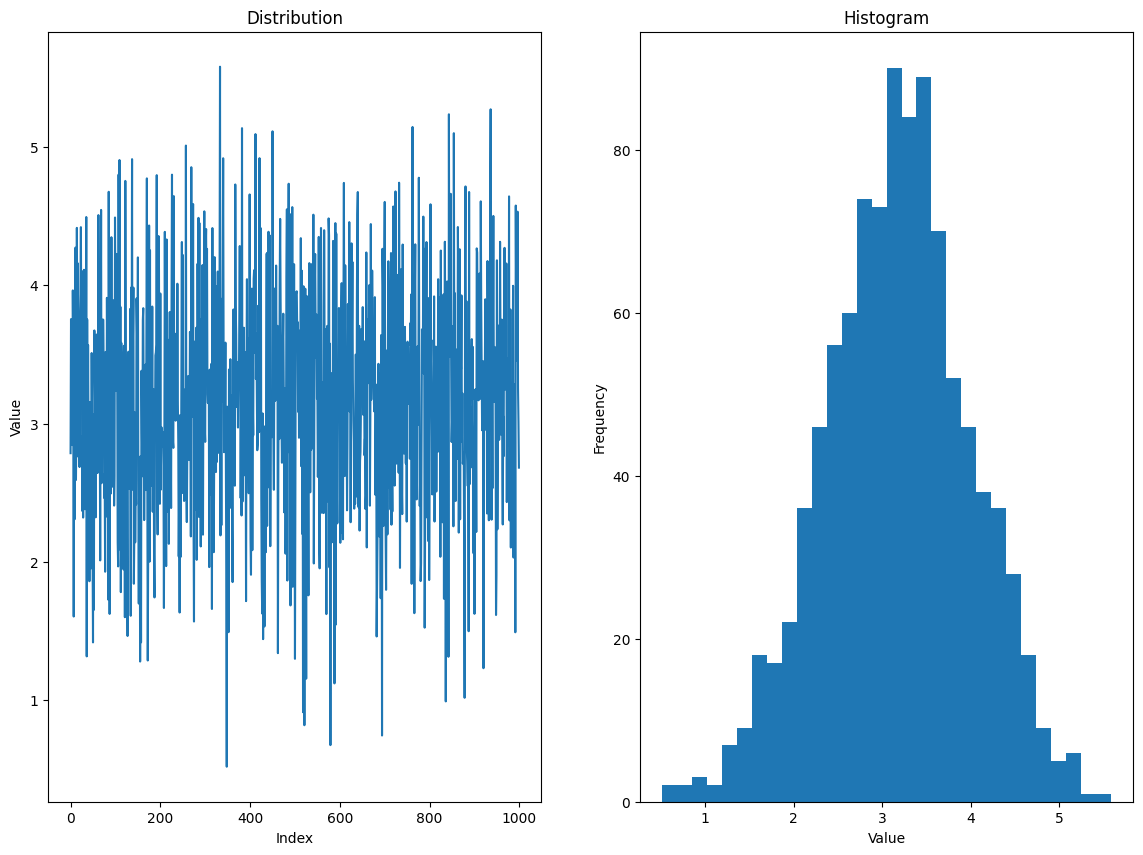

Distribution mean: 3.1693
Distribution std: 0.8114


In [2]:
#@markdown $\mu$ = numpy.pi. We have 1,000 points in this distribution.
sigma = 0.8 #@param {'type' : 'number'}

distribution = (np.random.randn(1000)*sigma)+np.pi

fig, axes = plt.subplots(1, 2, figsize=(14, 10))
axes[0].plot(distribution)
axes[0].set_title('Distribution')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Value')
axes[1].hist(distribution, bins=30)
axes[1].set_title('Histogram')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')
plt.show()

print(f'Distribution mean: {distribution.mean():.4f}')
print(f'Distribution std: {distribution.std():.4f}')

## Sampling

Now, let's sample from our distribution. We will generate a different amount of samples and compute their means.

Let's test $[5, 10, 20, 50, 100, 250]$ for instance.

In [3]:
sampling_size = [2, 5, 10, 20, 50, 100, 250]

for n in sampling_size:
  mean_sample = ((np.random.randn(n)*sigma)+np.pi).mean()
  print(f'Sample size = {n:4d}  Sample mean = {mean_sample:.4f}')

Sample size =    2  Sample mean = 3.1208
Sample size =    5  Sample mean = 2.9894
Sample size =   10  Sample mean = 2.7372
Sample size =   20  Sample mean = 3.0298
Sample size =   50  Sample mean = 3.2456
Sample size =  100  Sample mean = 3.0593
Sample size =  250  Sample mean = 3.0705


As expected, the more we sample, the closer we get to the distribution mean. So far, so good.

But, how do **a lot** of sample means behave?

Sample mean: 3.1212
Sample std: 0.2585
Theoretical standard error: 0.252982


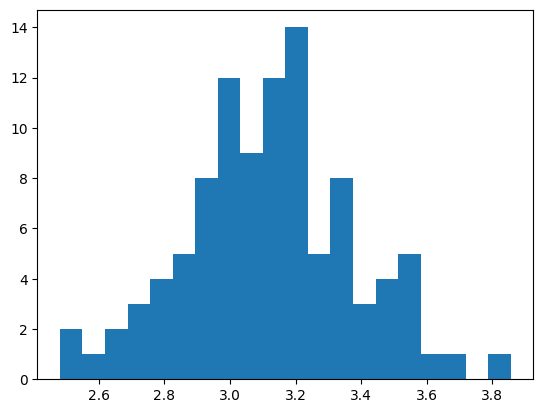

In [4]:
number_of_repeats = 100 #@param {'type' : 'number'}
sample_size = 10 #@param {'type' : 'number'}

sample_means = []

for _ in range(number_of_repeats):
  sample_means.append(((np.random.randn(sample_size)*sigma)+np.pi).mean())


plt.hist(sample_means, bins=20)

print(f'Sample mean: {np.mean(sample_means):.4f}')
print(f'Sample std: {np.std(sample_means):.4f}')

print(f'Theoretical standard error: {sigma/np.sqrt(sample_size):4f}')


As the number of repeats increase, we get mean values that approach the distribution mean.

But, surprisingly, as $n$ increases, we also get a new standard deviation that approaches

$
\frac{\sigma}{\sqrt{n}}
$

This is interesting, but maybe is also somewhat expected.

Now, what happens if we do exactly the same thing for a non-Gaussian distribution?

# Case 2 - An exponential decay

Let's generate an exponential decay distribution. A function like

$
y = A e^{-\gamma x}
$

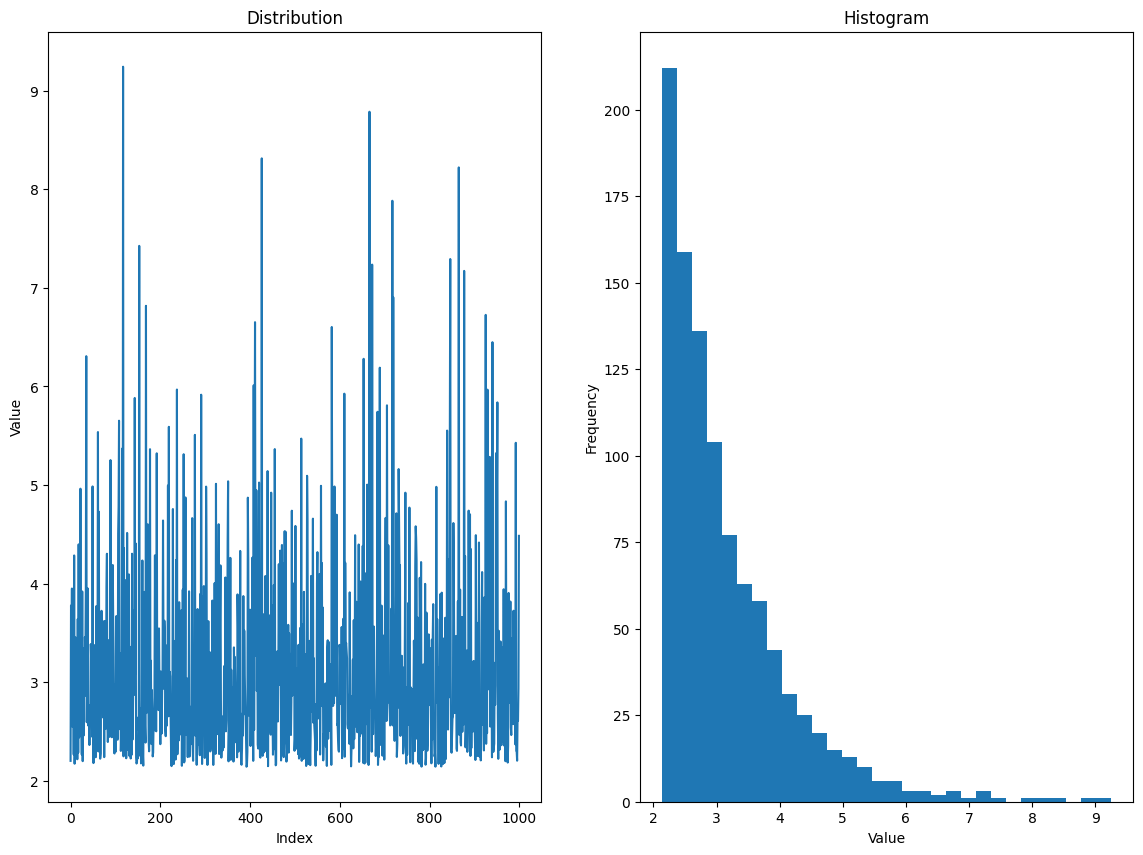

Distribution mean: 3.1433
Distribution std: 0.9939


In [5]:
#@markdown We will generate a distribution $y = 1 e^{-\gamma x}$ with 1,000 points.
gamma=1.0 #@param {'type' : 'number'}

exp_distribution = np.random.exponential(scale=1/gamma, size=1000)+np.pi-1.

fig, axes = plt.subplots(1, 2, figsize=(14, 10))
axes[0].plot(exp_distribution)
axes[0].set_title('Distribution')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Value')
axes[1].hist(exp_distribution, bins=30)
axes[1].set_title('Histogram')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')
plt.show()

print(f'Distribution mean: {exp_distribution.mean():.4f}')
print(f'Distribution std: {exp_distribution.std():.4f}')

Again, let's sample from this distribution **a lot of times** and see what we get.



Sample mean: 3.1267
Sample std: 0.1764
Theoretical standard error: 0.182574


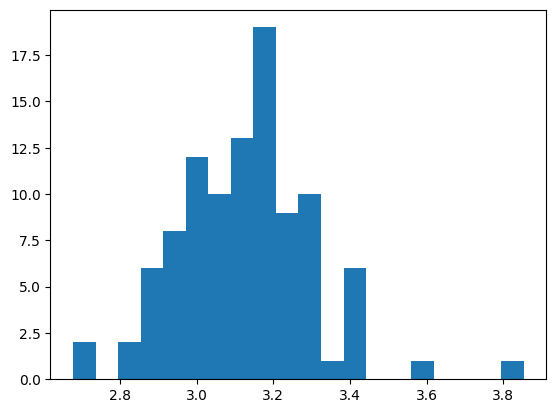

In [6]:
number_of_repeats = 100 #@param {'type' : 'number'}
sample_size = 30 #@param {'type' : 'number'}

sample_means = []

for _ in range(number_of_repeats):
  sample_means.append((np.random.exponential(scale=1/gamma, size=sample_size)+np.pi-1.).mean())


plt.hist(sample_means, bins=20)

print(f'Sample mean: {np.mean(sample_means):.4f}')
print(f'Sample std: {np.std(sample_means):.4f}')

print(f'Theoretical standard error: {1.0/np.sqrt(sample_size):4f}')


# Case 3: A Uniform distribution

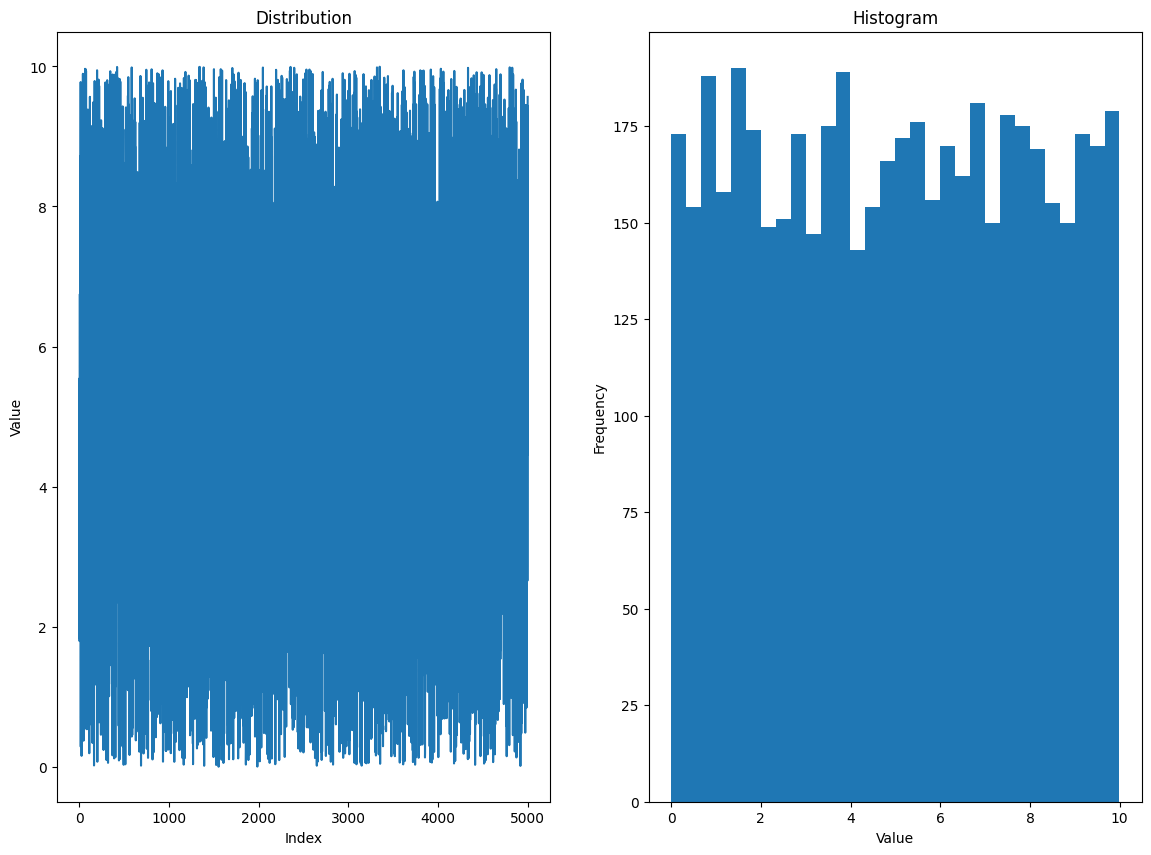

Distribution mean: 4.9988
Distribution std: 2.8990


In [7]:
#@markdown We will generate a distribution where values betweeen *low* and *high* are sampled uniformly.
#@markdown We will generate 5,000 points
low = 0 #@param {'type' : 'number'}
high = 10 #@param {'type' : 'number'}

uni_distribution = np.random.uniform(low=low, high=high, size=5000)

fig, axes = plt.subplots(1, 2, figsize=(14, 10))
axes[0].plot(uni_distribution)
axes[0].set_title('Distribution')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Value')
axes[1].hist(uni_distribution, bins=30)
axes[1].set_title('Histogram')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')
plt.show()

print(f'Distribution mean: {uni_distribution.mean():.4f}')
print(f'Distribution std: {uni_distribution.std():.4f}')

## Sampling from the Uniform Distribution

Sample mean: 5.0245
Sample std: 0.5331
Theoretical standard error: 0.529290


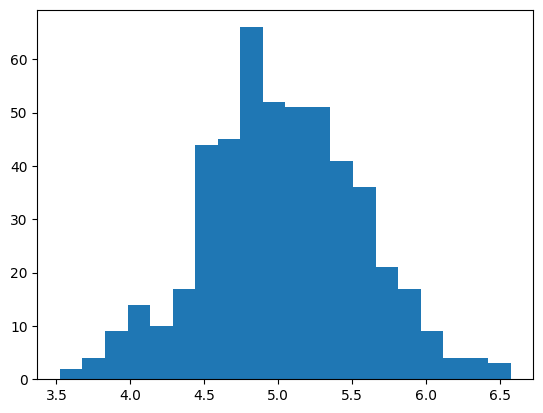

In [8]:
number_of_repeats = 500 #@param {'type' : 'number'}
sample_size = 30 #@param {'type' : 'number'}

sample_means = []

for _ in range(number_of_repeats):
  sample_means.append((np.random.uniform(low=low, high=high, size=30)).mean())

plt.hist(sample_means, bins=20)

print(f'Sample mean: {np.mean(sample_means):.4f}')
print(f'Sample std: {np.std(sample_means):.4f}')

print(f'Theoretical standard error: {uni_distribution.std()/np.sqrt(sample_size):4f}')


# Comparing means with sample size

We now repeat the same demonstration for the exponential decay as a function of the sample size.

We sample $N=1,000$ times from the exponential distribution, taking samples of sizes $[1, 2, 5, 10, 30, 50, 100]$. For every sample, we plot how the means behave and compute their means and standard deviations and compare to the population mean ($\mu$) and the standard error ($\sigma/\sqrt{n}$).

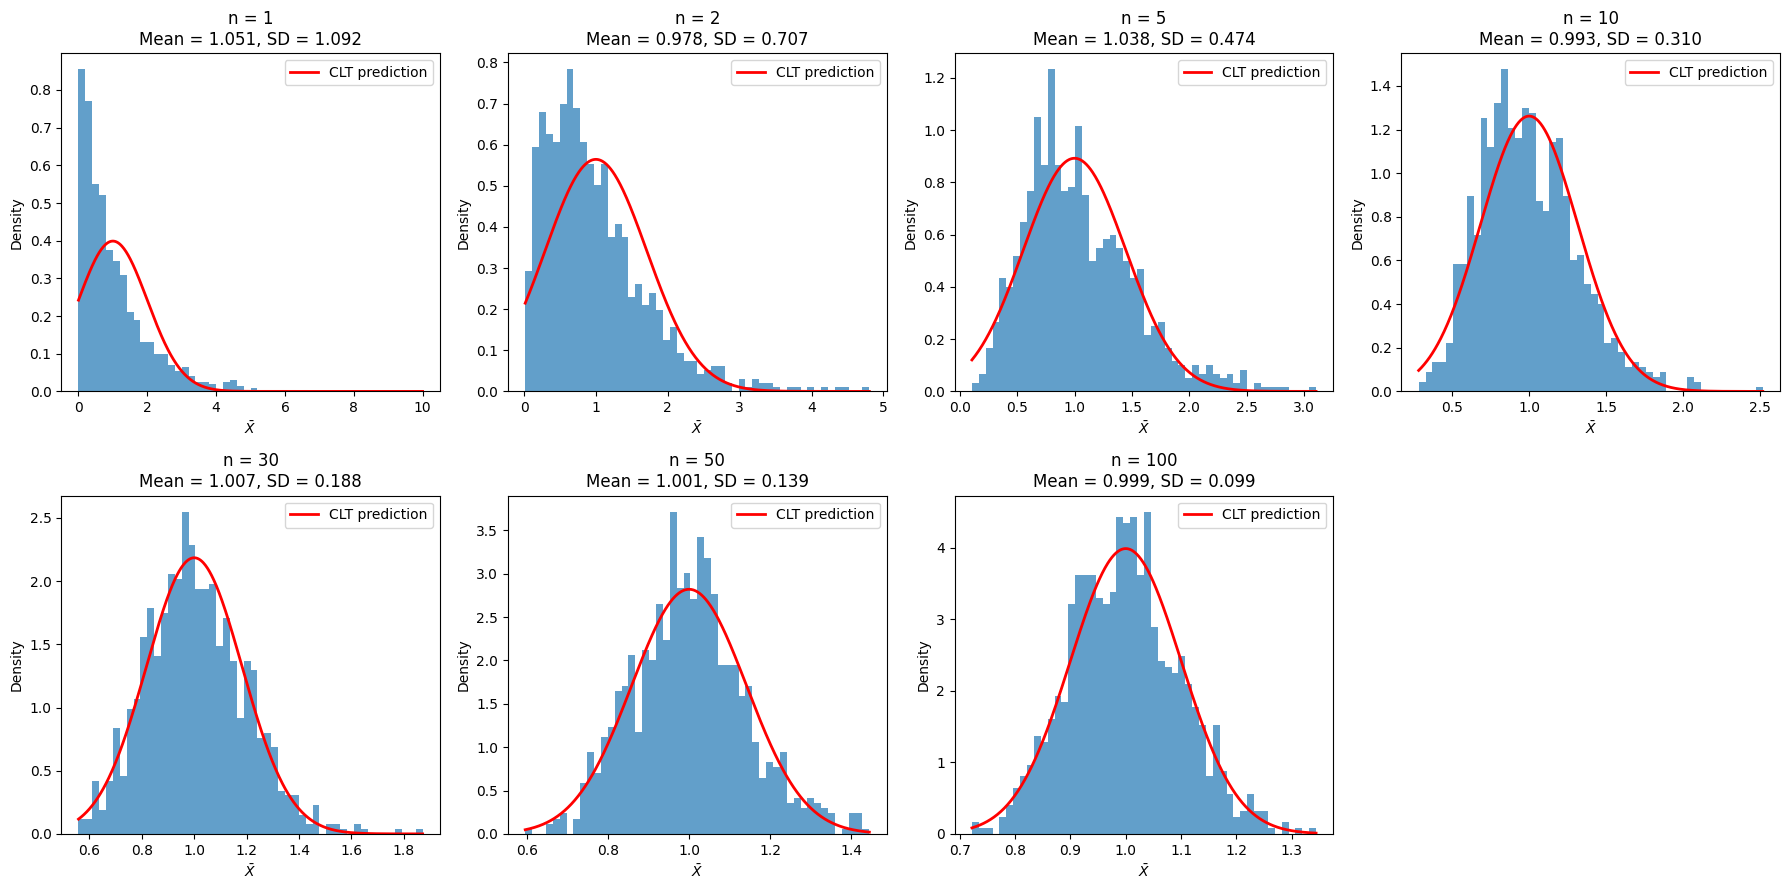

In [9]:
#@title Sampling from an exponential distribution as a function of sample size (n)
#@markdown $\mu=1$ and $\sigma=1$.

# Parameters of the original exponential distribution
lam = 1
mu = 1 / lam
sigma = 1 / lam

# Number of repeated samples
num_samples = 1000

# Sample sizes to investigate
sample_sizes = [1, 2, 5, 10, 30, 50, 100]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, n in enumerate(sample_sizes):

    # Generate num_samples independent samples,
    # each containing n observations
    samples = np.random.exponential(scale=1/lam, size=(num_samples, n))

    # Calculate the mean of each sample
    sample_means = samples.mean(axis=1)

    # Plot distribution of sample means
    axes[i].hist(sample_means, bins=50, density=True, alpha=0.7)

    # Theoretical CLT prediction
    predicted_std = sigma / np.sqrt(n)

    axes[i].set_title(f"n = {n}\n"
        f"Mean = {sample_means.mean():.3f}, "
        f"SD = {sample_means.std():.3f}")

    axes[i].set_xlabel(r"$\bar{X}$")
    axes[i].set_ylabel("Density")

    # Plot predicted normal distribution
    x = np.linspace(sample_means.min(), sample_means.max(), 500)

    normal_pdf = (1 / (predicted_std * np.sqrt(2*np.pi)) * np.exp(-(x - mu)**2 / (2 * predicted_std**2)))

    axes[i].plot(x, normal_pdf, 'r-', linewidth=2, label='CLT prediction')

    axes[i].legend()

# Hide unused subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()


# Advanced skills!

Now, let's see how the different means for $n = [5, 30, 100]$ behave in a quantile-quantile (Q-Q) plot.

We will use the Q-Q plot from Scipy stats function

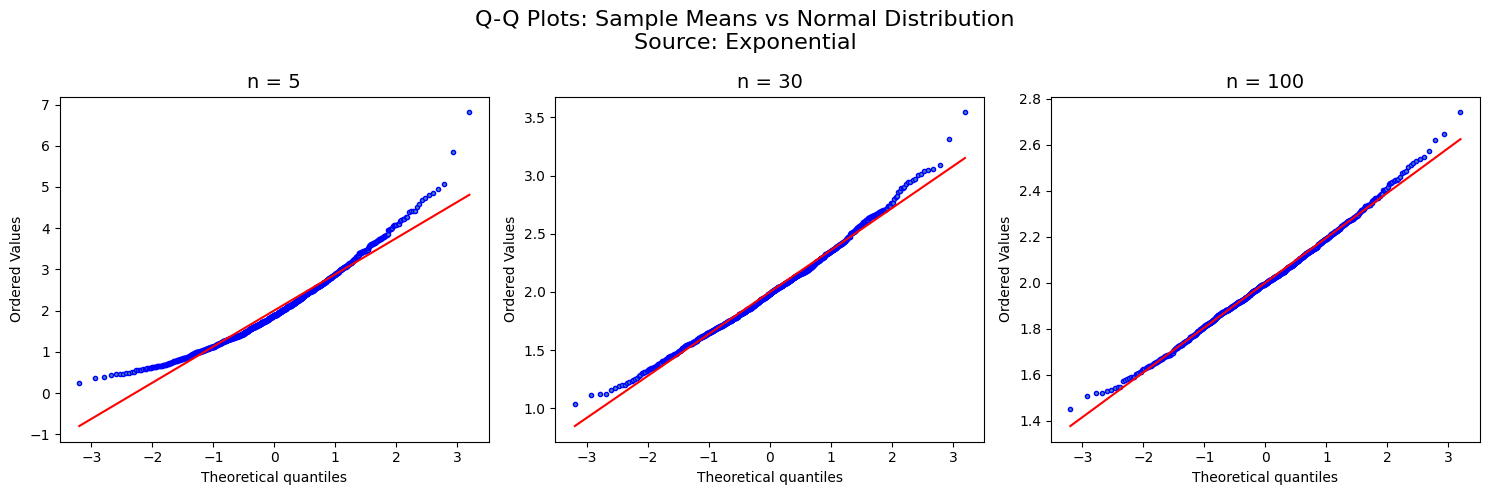

In [10]:
#@title Q-Q plot for an exponential distribution
q_q_plot_clt(source_dist='exponential', n_values=[5, 30, 100])

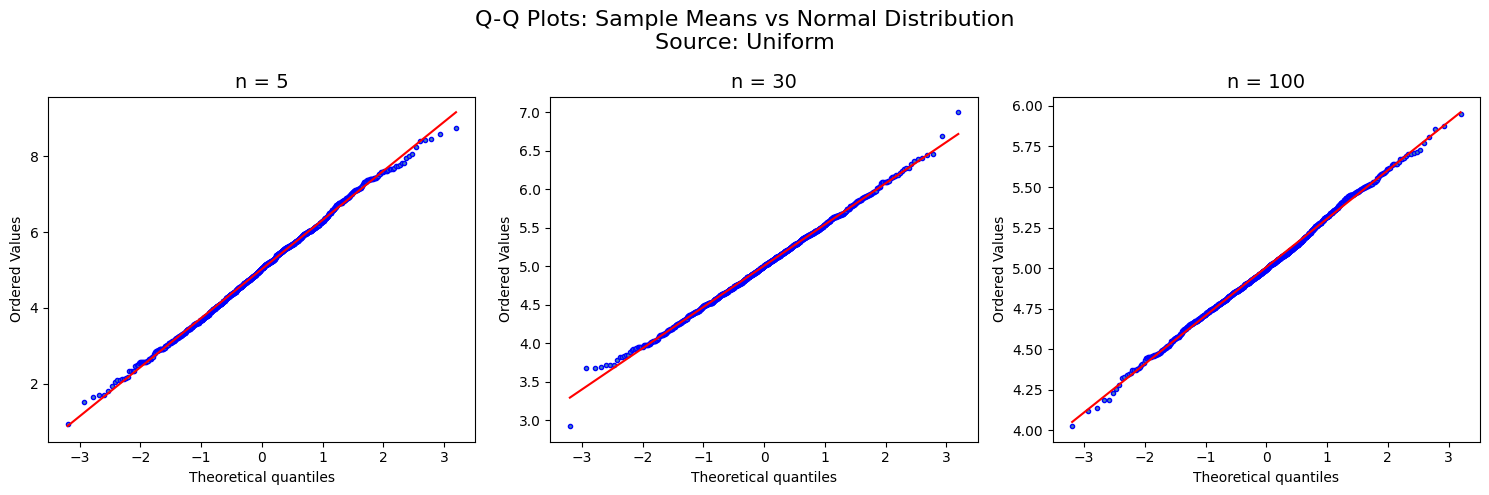

In [11]:
#@title Q-Q plot for an uniform distribution
q_q_plot_clt(source_dist='uniform', n_values=[5, 30, 100])

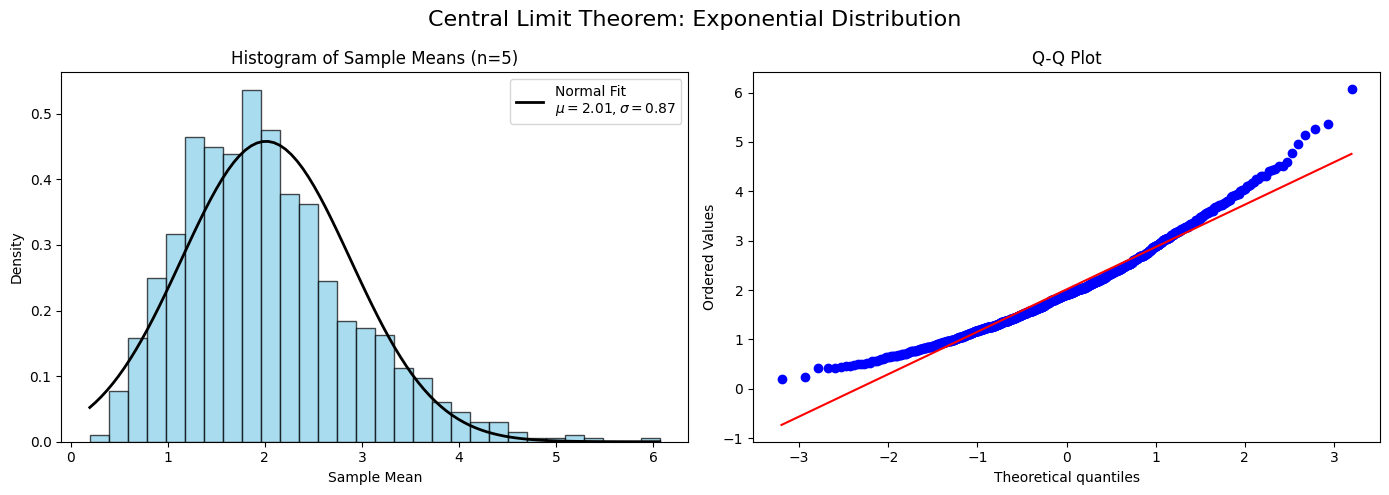

Original data mean: 2.0029
Original data std: 1.9822


In [12]:
#@title Q-Q Plot with histogram

n = 5 #@param {'type' : 'number'}
scale = 2.0 #@param {'type' : 'number'}
size = 500 #@param {'type' : 'number'}


exponential_data = np.random.exponential(scale=scale, size=size)

plot_clt_demo(exponential_data, n=n, dist_name="Exponential Distribution")
print(f'Original data mean: {exponential_data.mean():.4f}')
print(f'Original data std: {exponential_data.std():.4f}')

# Computing the area under the curve for the standard normal curve

In [13]:
z = 2.0 #@param {'type' : 'number'}

cdf = norm.cdf(z, loc=0, scale=1)
print(f'P[Z<{z}] = {cdf:.4f}')
print(f'P[Z>{z}] = {1-cdf:.4f}')

P[Z<2.0] = 0.9772
P[Z>2.0] = 0.0228
